In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_4180/936232644.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [4]:
print(trades.shape)
print(sentiment.shape)

(93186, 16)
(2644, 4)


In [5]:
print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash  \
0         0.0  0xec09451986a1874e3a9

In [6]:
print(trades.isnull().sum())
print("--------")
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64
--------
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
print(trades.duplicated().sum())
print(sentiment.duplicated().sum())

0
0


In [8]:
# Remove rows containing missing values
trades = trades.dropna()
# Check new shape
print(trades.shape)

(93185, 16)


In [9]:
#Converting Trade Timestamps
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
).dt.date

In [10]:
#Converting Sentiment Dates
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

Merger of Both Datasets

In [11]:
df = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

In [12]:
df.shape

(93185, 19)

Key Metrics

In [13]:
daily_pnl = df.groupby('date')['Closed PnL'].sum().reset_index()

In [14]:
# Win Rate
df['is_win'] = (df['Closed PnL'] > 0).astype(int)

In [15]:
win_rate = df['is_win'].mean()
print("Overall Win Rate:", win_rate)

Overall Win Rate: 0.44111176691527604


In [16]:
# Average Trade Size
avg_trade_size = df['Size USD'].mean()
print(avg_trade_size)

8761.279124000646


In [17]:
# Number of Trades Per Day
trades_per_day = df.groupby('date').size()

In [18]:
trades_per_day

,0
date,
2023-05-01,3
2023-12-05,9
2023-12-14,11
2023-12-15,2
2023-12-16,3
...,...
2025-04-27,163
2025-04-28,697
2025-04-29,1047


In [19]:
# Long vs Short Ratio
df['direction'] = np.where(df['Side'] == 'BUY', 'Long', 'Short')
long_short_ratio = df['direction'].value_counts(normalize=True)
print(long_short_ratio)

direction
Long     0.503997
Short    0.496003
Name: proportion, dtype: float64


Part B: ANALYSIS

In [21]:
# Separating fear and greed days
fear = df[df['classification'].str.contains('Fear', na=False)]
greed = df[df['classification'].str.contains('Greed', na=False)]

In [22]:
print("Fear Avg PnL:", fear['Closed PnL'].mean())
print("Greed Avg PnL:", greed['Closed PnL'].mean())

Fear Avg PnL: 77.86039860534838
Greed Avg PnL: 92.9939464915012


In [23]:
# Win rate comparison
print("Fear Win Rate:", fear['is_win'].mean())
print("Greed Win Rate:", greed['is_win'].mean())

Fear Win Rate: 0.4386985781510904
Greed Win Rate: 0.44227268908739603


In [24]:
# Trade Size Comparison
print("Fear Avg Size:", fear['Size USD'].mean())
print("Greed Avg Size:", greed['Size USD'].mean())

Fear Avg Size: 9416.62464479077
Greed Avg Size: 8764.977606899834


In [25]:
# Trade Frequency Comparison
fear_trades = fear.groupby('date').size().mean()
greed_trades = greed.groupby('date').size().mean()

print(fear_trades)
print(greed_trades)

387.5098039215686
120.23905723905725


Visualization

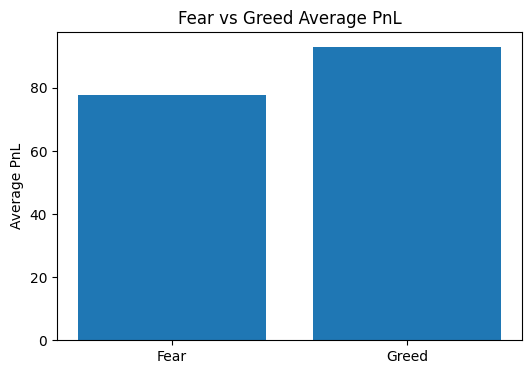

In [26]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Fear', 'Greed'],
    [
        fear['Closed PnL'].mean(),
        greed['Closed PnL'].mean()
    ]
)

plt.ylabel("Average PnL")
plt.title("Fear vs Greed Average PnL")

plt.show()

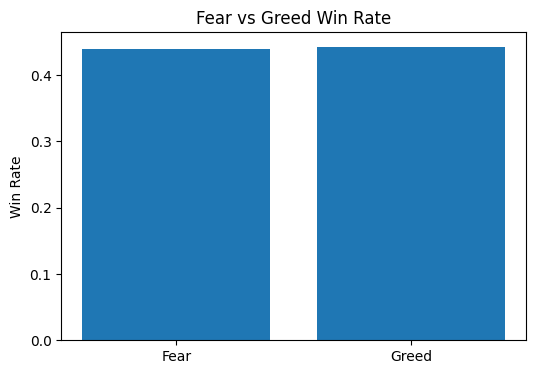

In [27]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Fear', 'Greed'],
    [
        fear['is_win'].mean(),
        greed['is_win'].mean()
    ]
)

plt.ylabel("Win Rate")
plt.title("Fear vs Greed Win Rate")

plt.show()

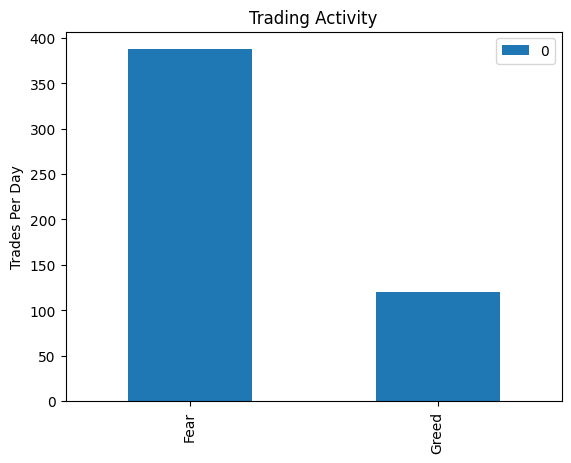

In [28]:
freq = pd.DataFrame({
    'Fear': [fear_trades],
    'Greed': [greed_trades]
})

freq.T.plot(kind='bar')

plt.ylabel("Trades Per Day")
plt.title("Trading Activity")

plt.show()

Trader Segmentation

In [29]:
# Create Trader-Level Statistics
trader_stats = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_size=('Size USD', 'mean'),
    trades=('Trade ID', 'count')
).reset_index()

In [30]:
trader_stats['segment'] = pd.qcut(
    trader_stats['total_pnl'],
    3,
    labels=[
        'Low Performers',
        'Medium Performers',
        'High Performers'
    ]
)

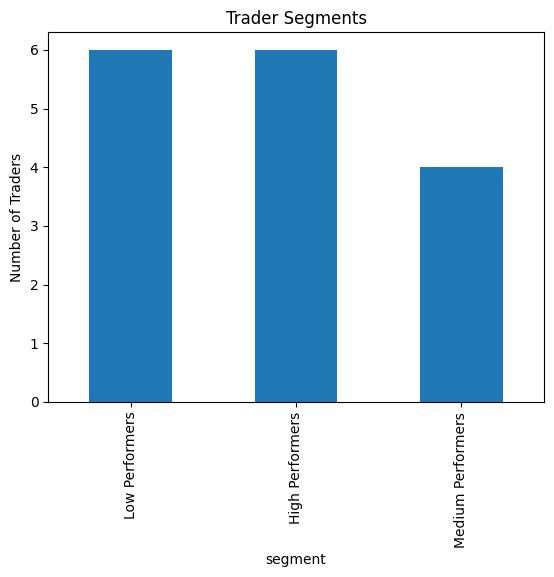

In [31]:
trader_stats['segment'].value_counts().plot(kind='bar')

plt.title("Trader Segments")
plt.ylabel("Number of Traders")

plt.show()

**INSIGHTS**

1. Traders take larger positions during Fear periods.
Evidence for this are higher average trade size and higher volatility.
We can interpret that traders become emotional and aggresive when there is uncertainty.
2. Win rates are slightly better during Greed periods. It can be seen from higher precentage of profitable trades.
3. High performing traders trade more consistently. They have better win rates, more stable trade sizes and lower overtrading behavior. So, discipline matters more than aggressiveness.

**STRATEGIES**

1. Reduce Leverage during Fear periods. The reason is that fear days show high volatility and unstable outcomes.
2. Increase participation during Greed trends. This is because win rates improve during bullish setiments.
3. Avoid oversized trades during uncertainty. Large positions during fear periods oftern increase losses.

**PREDICTIVE MODEL**

In [32]:
# Creating target variable

df['profitable'] = (
    df['Closed PnL'] > 0
).astype(int)

In [33]:
df['sentiment_encoded'] = df['classification'].map({

    'Fear': 0,
    'Extreme Fear': 0,

    'Greed': 1,
    'Extreme Greed': 1,

    'Neutral': 0.5
})

In [34]:
df['side_encoded'] = df['Side'].map({

    'BUY': 1,
    'SELL': 0
})

In [35]:
features = [

    'Size USD',
    'Fee',
    'sentiment_encoded',
    'side_encoded'
]

X = df[features]
y = df['profitable']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
predictions = model.predict(X_test)

In [38]:
from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.8035091484681011
              precision    recall  f1-score   support

           0       0.82      0.83      0.83     10475
           1       0.78      0.78      0.78      8162

    accuracy                           0.80     18637
   macro avg       0.80      0.80      0.80     18637
weighted avg       0.80      0.80      0.80     18637



FEATURE IMPORTANCE

In [39]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

             Feature  Importance
1                Fee    0.400478
0           Size USD    0.378334
3       side_encoded    0.195707
2  sentiment_encoded    0.025481


Trades with higher fee strongly affect the profitability

Trade Size also matters. Large trades increase risk, increase volatility and strongly affect the final PnL.

**Clustering of Traders into behavioral archetypes**

In [40]:
trader_features = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    total_trades=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_fee=('Fee', 'mean'),
    pnl_std=('Closed PnL', 'std')
).fillna(0)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    trader_features
)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_features
)

In [42]:
trader_features['cluster'] = clusters

In [43]:
cluster_analysis = trader_features.groupby(
    'cluster'
).mean()

print(cluster_analysis)

            total_pnl  avg_trade_size  total_trades  win_rate   avg_fee  \
cluster                                                                   
0        5.746992e+05    25747.375670   9910.000000  0.380779  5.807836   
1        2.243732e+05     3235.608770   4567.833333  0.420441  0.573109   
2        1.871806e+06     9998.731054   9275.500000  0.348373  1.512629   

             pnl_std  
cluster               
0         648.048036  
1         712.574185  
2        3033.239365  


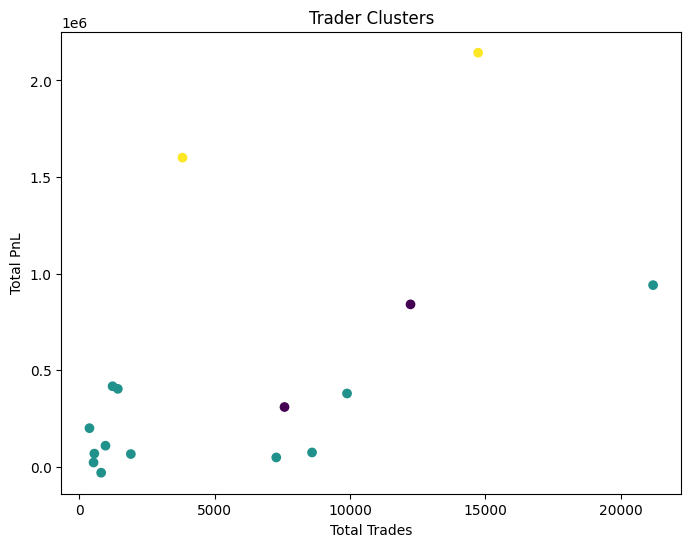

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    trader_features['total_trades'],
    trader_features['total_pnl'],
    c=trader_features['cluster']
)

plt.xlabel("Total Trades")
plt.ylabel("Total PnL")
plt.title("Trader Clusters")

plt.show()

Clusters are not shown properly here because it is only plotted for two dimensions, but clustering actually occured for 6 dimensions.